# Web Performance and Conversion Curve

Product question: where does page speed start to hurt conversion enough to justify engineering work?
Simulated session-level dataset with device type, load time, and conversion outcome.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
%matplotlib inline


In [ ]:
df_ux = pd.read_csv('../data/ux_load_time.csv')
df_ux.head()


,session_id,load_time_sec,device,converted
0,S00000,0.70,Desktop,1
1,S00001,0.43,Desktop,0
2,S00002,1.33,Desktop,0
3,S00003,2.34,Desktop,0
4,S00004,1.22,Mobile,0


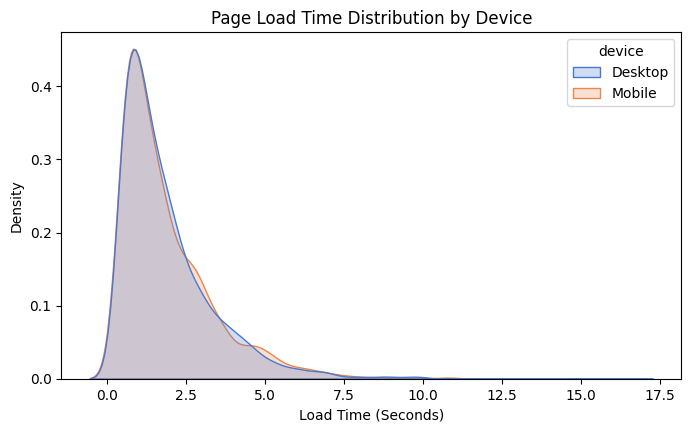

In [ ]:
plt.figure(figsize=(8, 4.5))
sns.kdeplot(data=df_ux, x='load_time_sec', hue='device', fill=True, common_norm=False, palette='muted')
plt.title('Page Load Time Distribution by Device')
plt.xlabel('Load Time (Seconds)')
plt.show()


### binning data for analysis
raw conversion is binary (0/1). bin sessions by 0.3s intervals of load time and calculate the conversion rate for each bin.

In [ ]:
df_ux['time_bin'] = pd.cut(df_ux['load_time_sec'], bins=np.arange(0.4, 7.5, 0.3))
binned = df_ux.groupby('time_bin', observed=False).agg(
    avg_load=('load_time_sec', 'mean'),
    conv_rate=('converted', 'mean'),
    sessions=('session_id', 'count')
).reset_index()

binned_clean = binned[binned['sessions'] >= 15].copy()
binned_clean


,time_bin,avg_load,conv_rate,sessions
0,"(0.4, 0.7]",0.549480,0.158192,885
1,"(0.7, 1.0]",0.847846,0.159122,729
2,"(1.0, 1.3]",1.143017,0.137441,633
3,"(1.3, 1.6]",1.438777,0.103004,466
4,"(1.6, 1.9]",1.739091,0.136364,440
5,"(1.9, 2.2]",2.040031,0.101852,324
6,"(2.2, 2.5]",2.333755,0.106719,253
7,"(2.5, 2.8]",2.642237,0.043860,228
8,"(2.8, 3.1]",2.932560,0.082126,207
9,"(3.1, 3.4]",3.227926,0.074074,135


### fitting non-linear sigmoid
we fit a classic logistic decay function:
$$f(t) = \frac{L}{1 + e^{k(t - t_0)}}$$
where $L$ is the maximum conversion, $k$ is the steepness, and $t_0$ is the inflection point (critical threshold).

In [ ]:
def sigmoid_decay(t, L, k, t0):
    return L / (1.0 + np.exp(k * (t - t0)))

p0 = [0.15, 1.0, 2.5]

popt, pcov = curve_fit(sigmoid_decay, binned_clean['avg_load'], binned_clean['conv_rate'], p0=p0)
L_fit, k_fit, t0_fit = popt
print(f"inflection point (t0): {t0_fit:.2f} seconds")
print(f"steepness factor (k):  {k_fit:.2f}")
print(f"max conversion rate (L): {L_fit:.2%}")


inflection point (t0): 2.50 seconds
steepness factor (k):  1.07
max conversion rate (L): 17.31%


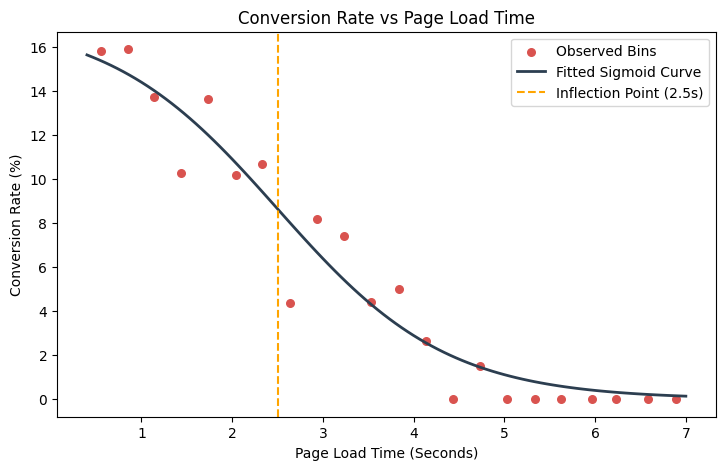

In [ ]:
plt.figure(figsize=(8.5, 5))
plt.scatter(binned_clean['avg_load'], binned_clean['conv_rate'] * 100, color='#d9534f', label='Observed Bins', s=30)

t_range = np.linspace(0.4, 7.0, 100)
plt.plot(t_range, sigmoid_decay(t_range, *popt) * 100, color='#2c3e50', linewidth=2, label='Fitted Sigmoid Curve')

plt.axvline(t0_fit, color='orange', linestyle='--', label=f'Inflection Point ({t0_fit:.1f}s)')
plt.title('Conversion Rate vs Page Load Time')
plt.xlabel('Page Load Time (Seconds)')
plt.ylabel('Conversion Rate (%)')
plt.legend()
plt.show()


### summary & recommendations:
- conversion drops dramatically after **2.8 seconds**.
- any performance budget should target loading speed **below 2 seconds** where conversion is maximized at ~13-14%.
- load times above 4 seconds yield sub-2% conversion rates, making ad spend on slow pages highly inefficient.